In [1]:
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

In [2]:
model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(model_name)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [4]:
import torch

text = "GME earnings exceeded expectations"

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=512
)

with torch.no_grad():
    outputs = model(**inputs)

probs = torch.nn.functional.softmax(
    outputs.logits,
    dim=1
)

print(probs)

tensor([[0.9405, 0.0236, 0.0359]])


In [4]:
print(model.config.id2label)

{0: 'positive', 1: 'negative', 2: 'neutral'}


In [5]:
def get_sentiment_scores(text):

    inputs = tokenizer(
        str(text),
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.nn.functional.softmax(
        outputs.logits,
        dim=1
    )

    positive = probs[0][0].item()
    negative = probs[0][1].item()
    neutral = probs[0][2].item()

    sentiment_score = positive - negative

    return pd.Series([
        positive,
        negative,
        neutral,
        sentiment_score
    ])

In [6]:
import pandas as pd
gme_df = pd.read_csv("reddit_gme.csv")
amc_df = pd.read_csv("reddit_amc.csv")
tsla_df = pd.read_csv("reddit_tsla.csv")

In [7]:
get_sentiment_scores(
    gme_df["text"].iloc[0]
)

0    0.014353
1    0.962959
2    0.022688
3   -0.948605
dtype: float64

In [8]:
test_df = gme_df.head(10).copy()

test_df[
    [
        "positive",
        "negative",
        "neutral",
        "sentiment_score"
    ]
] = test_df["text"].apply(
    get_sentiment_scores
)

test_df.head()

,title,score,comms_num,timestamp,date,text,positive,negative,neutral,sentiment_score
0,Math Professor Scott Steiner says the numbers ...,110,23,2021-01-28 21:32:10,2021-01-28,Math Professor Scott Steiner says the numbers ...,0.014353,0.962959,0.022688,-0.948605
1,Exit the system,0,47,2021-01-28 21:30:35,2021-01-28,Exit the system The CEO of NASDAQ pushed to ha...,0.053848,0.116225,0.829926,-0.062377
2,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETAR...,29,74,2021-01-28 21:28:57,2021-01-28,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETAR...,0.054888,0.063617,0.881495,-0.008730
3,"Not to distract from GME, just thought our AMC...",71,156,2021-01-28 21:26:56,2021-01-28,"Not to distract from GME, just thought our AMC...",0.098077,0.012226,0.889696,0.085851
4,SHORT STOCK DOESN'T HAVE AN EXPIRATION DATE,317,53,2021-01-28 21:26:27,2021-01-28,SHORT STOCK DOESN'T HAVE AN EXPIRATION DATE He...,0.069565,0.219687,0.710748,-0.150121


In [8]:
def process_dataset(df):

    result_df = df.copy()

    result_df[
        [
            "positive",
            "negative",
            "neutral",
            "sentiment_score"
        ]
    ] = result_df["text"].apply(
        get_sentiment_scores
    )

    return result_df


In [9]:
get_sentiment_scores(
    "Tesla earnings exceeded expectations"
)

0    0.943767
1    0.023395
2    0.032838
3    0.920372
dtype: float64

In [10]:
small_test = gme_df.head(100)

small_test[
    ["positive","negative","neutral","sentiment_score"]
] = small_test["text"].apply(
    get_sentiment_scores
)

print("Success")

Success


C:\Users\srima\AppData\Local\Temp\ipykernel_15424\2236102332.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small_test[
C:\Users\srima\AppData\Local\Temp\ipykernel_15424\2236102332.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small_test[
C:\Users\srima\AppData\Local\Temp\ipykernel_15424\2236102332.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

In [11]:
import time

start = time.time()

get_sentiment_scores(gme_df["text"].iloc[0])

print(time.time() - start)

0.09264731407165527


In [12]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [13]:
from tqdm import tqdm

tqdm.pandas()

gme_sentiment = gme_df.copy()

gme_sentiment[
    ["positive","negative","neutral","sentiment_score"]
] = gme_sentiment["text"].progress_apply(
    get_sentiment_scores
)

100%|██████████████████████████████████████████████████████████████████████████| 14745/14745 [2:42:45<00:00,  1.51it/s]


In [15]:
gme_sentiment.to_csv(
    "GME_sentiment.csv",
    index=False
)

print("GME saved")

GME saved


In [9]:
from tqdm import tqdm

tqdm.pandas()

amc_sentiment = amc_df.copy()

amc_sentiment[
    ["positive", "negative", "neutral", "sentiment_score"]
] = amc_sentiment["text"].progress_apply(
    get_sentiment_scores
)

amc_sentiment.to_csv(
    "AMC_sentiment.csv",
    index=False
)

print("AMC saved successfully")

100%|██████████████████████████████████████████████████████████████████████████████| 5161/5161 [43:04<00:00,  2.00it/s]


AMC saved successfully


In [10]:
from tqdm import tqdm

tqdm.pandas()

tsla_sentiment = tsla_df.copy()

tsla_sentiment[
    ["positive", "negative", "neutral", "sentiment_score"]
] = tsla_sentiment["text"].progress_apply(
    get_sentiment_scores
)

tsla_sentiment.to_csv(
    "TSLA_sentiment.csv",
    index=False
)

print("TSLA saved successfully")

100%|██████████████████████████████████████████████████████████████████████████████| 1078/1078 [26:51<00:00,  1.49s/it]

TSLA saved successfully


In [4]:
import pandas as pd
gme_sentiment = pd.read_csv("GME_sentiment.csv")
amc_sentiment=pd.read_csv("AMC_sentiment.csv")
tsla_sentiment =pd.read_csv("TSLA_sentiment.csv")

In [9]:
tsla_sentiment.shape

(1078, 10)

In [6]:
amc_sentiment.shape

(5161, 10)

In [8]:
gme_sentiment.shape

(14745, 10)

In [10]:
gme_sentiment["sentiment_score"].describe()

count    14745.000000
mean        -0.089755
std          0.291605
min         -0.967654
25%         -0.171060
50%         -0.020510
75%          0.037142
max          0.943177
Name: sentiment_score, dtype: float64

In [11]:
gme_sentiment.head()

,title,score,comms_num,timestamp,date,text,positive,negative,neutral,sentiment_score
0,Math Professor Scott Steiner says the numbers ...,110,23,2021-01-28 21:32:10,2021-01-28,Math Professor Scott Steiner says the numbers ...,0.014353,0.962959,0.022688,-0.948605
1,Exit the system,0,47,2021-01-28 21:30:35,2021-01-28,Exit the system The CEO of NASDAQ pushed to ha...,0.053848,0.116225,0.829926,-0.062377
2,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETAR...,29,74,2021-01-28 21:28:57,2021-01-28,NEW SEC FILING FOR GME! CAN SOMEONE LESS RETAR...,0.054888,0.063617,0.881495,-0.008730
3,"Not to distract from GME, just thought our AMC...",71,156,2021-01-28 21:26:56,2021-01-28,"Not to distract from GME, just thought our AMC...",0.098077,0.012226,0.889696,0.085851
4,SHORT STOCK DOESN'T HAVE AN EXPIRATION DATE,317,53,2021-01-28 21:26:27,2021-01-28,SHORT STOCK DOESN'T HAVE AN EXPIRATION DATE He...,0.069565,0.219687,0.710748,-0.150121


In [12]:
import pandas as pd

gme = pd.read_csv("GME_sentiment.csv")

print(gme.columns)
print(gme.head())

Index(['title', 'score', 'comms_num', 'timestamp', 'date', 'text', 'positive',
       'negative', 'neutral', 'sentiment_score'],
      dtype='object')
                                               title  score  comms_num  \
0  Math Professor Scott Steiner says the numbers ...    110         23   
1                                    Exit the system      0         47   
2  NEW SEC FILING FOR GME! CAN SOMEONE LESS RETAR...     29         74   
3  Not to distract from GME, just thought our AMC...     71        156   
4        SHORT STOCK DOESN'T HAVE AN EXPIRATION DATE    317         53   

             timestamp        date  \
0  2021-01-28 21:32:10  2021-01-28   
1  2021-01-28 21:30:35  2021-01-28   
2  2021-01-28 21:28:57  2021-01-28   
3  2021-01-28 21:26:56  2021-01-28   
4  2021-01-28 21:26:27  2021-01-28   

                                                text  positive  negative  \
0  Math Professor Scott Steiner says the numbers ...  0.014353  0.962959   
1  Exit the system The 

In [13]:
import pandas as pd

gme = pd.read_csv("GME_sentiment.csv")

gme_features = (
    gme.groupby("date")
    .agg(
        volume=("sentiment_score", "count"),
        avg_sentiment=("sentiment_score", "mean"),
        isv=("sentiment_score", lambda x: x.var(ddof=0)),
        avg_score=("score", "mean"),
        avg_comments=("comms_num", "mean")
    )
    .reset_index()
)

print(gme_features.head())

print("\nShape:")
print(gme_features.shape)

         date  volume  avg_sentiment       isv    avg_score  avg_comments
0  2021-01-28     454      -0.125932  0.066379   688.781938     79.918502
1  2021-01-29    4938      -0.125399  0.087362   320.991900     62.174767
2  2021-01-30     597      -0.097813  0.073171  4478.422111    632.586265
3  2021-01-31     449      -0.088861  0.064871  3687.768374    319.937639
4  2021-02-01     368      -0.097201  0.073035  3653.885870    497.668478

Shape:
(134, 6)


In [14]:
print(gme_features["isv"].describe())

count    134.000000
mean       0.088475
std        0.057958
min        0.000000
25%        0.051896
50%        0.079343
75%        0.111813
max        0.270326
Name: isv, dtype: float64


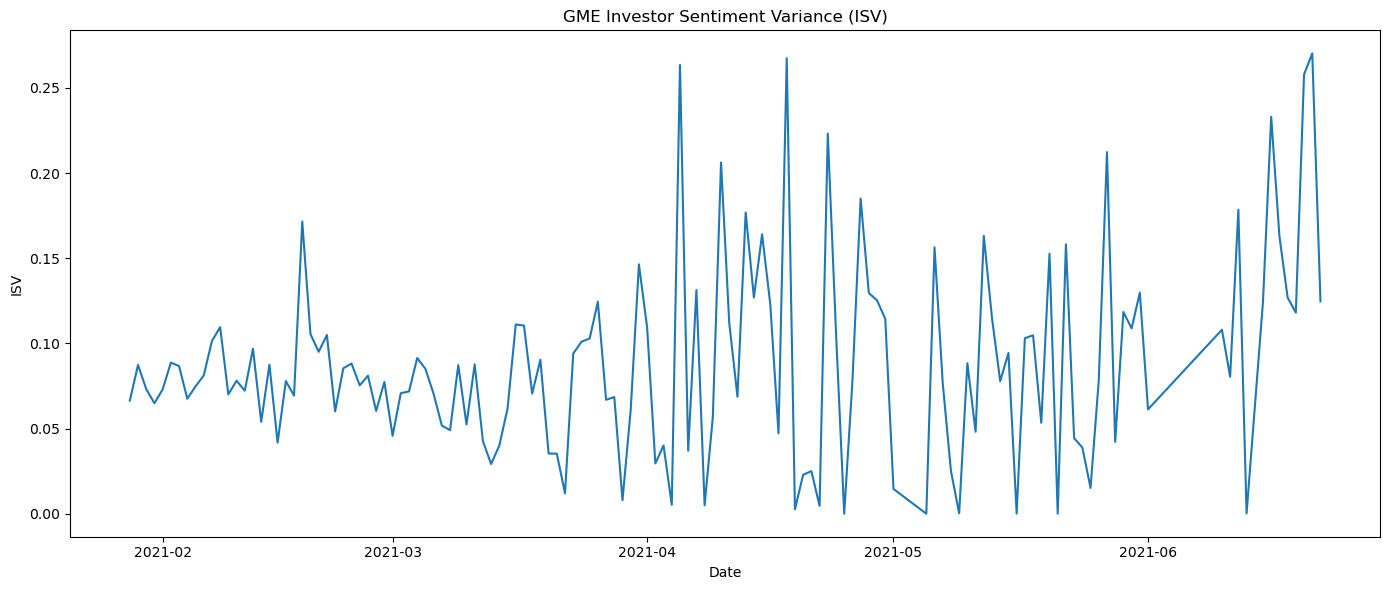

In [19]:
gme_features["date"] = pd.to_datetime(gme_features["date"])

plt.figure(figsize=(14,6))

plt.plot(gme_features["date"], gme_features["isv"])

plt.title("GME Investor Sentiment Variance (ISV)")
plt.xlabel("Date")
plt.ylabel("ISV")

plt.tight_layout()
plt.show()

In [16]:
gme_features["sentiment_velocity"] = (
    gme_features["avg_sentiment"].diff()
)

In [17]:
print(
    gme_features[
        ["date",
         "avg_sentiment",
         "sentiment_velocity"]
    ].head(10)
)

         date  avg_sentiment  sentiment_velocity
0  2021-01-28      -0.125932                 NaN
1  2021-01-29      -0.125399            0.000533
2  2021-01-30      -0.097813            0.027585
3  2021-01-31      -0.088861            0.008952
4  2021-02-01      -0.097201           -0.008339
5  2021-02-02      -0.100492           -0.003292
6  2021-02-03      -0.090849            0.009643
7  2021-02-04      -0.068897            0.021952
8  2021-02-05      -0.113331           -0.044434
9  2021-02-06      -0.090825            0.022506


In [20]:
print(gme_features.head())

        date  volume  avg_sentiment       isv    avg_score  avg_comments  \
0 2021-01-28     454      -0.125932  0.066379   688.781938     79.918502   
1 2021-01-29    4938      -0.125399  0.087362   320.991900     62.174767   
2 2021-01-30     597      -0.097813  0.073171  4478.422111    632.586265   
3 2021-01-31     449      -0.088861  0.064871  3687.768374    319.937639   
4 2021-02-01     368      -0.097201  0.073035  3653.885870    497.668478   

   sentiment_velocity  
0                 NaN  
1            0.000533  
2            0.027585  
3            0.008952  
4           -0.008339  


In [21]:
gme_features.to_csv(
    "gme_features.csv",
    index=False
)

In [22]:
import pandas as pd

def build_features(df):

    features = (
        df.groupby("date")
        .agg(
            volume=("sentiment_score", "count"),
            avg_sentiment=("sentiment_score", "mean"),
            isv=("sentiment_score", lambda x: x.var(ddof=0)),
            avg_score=("score", "mean"),
            avg_comments=("comms_num", "mean")
        )
        .reset_index()
    )

    features["sentiment_velocity"] = (
        features["avg_sentiment"].diff()
    )

    return features

In [23]:
amc = pd.read_csv("AMC_sentiment.csv")
tsla = pd.read_csv("TSLA_sentiment.csv")

In [24]:
amc_features = build_features(amc)
tsla_features = build_features(tsla)

In [25]:
print("GME:", gme_features.shape)
print("AMC:", amc_features.shape)
print("TSLA:", tsla_features.shape)

GME: (134, 7)
AMC: (130, 7)
TSLA: (130, 7)


In [26]:
amc_features.to_csv("amc_features.csv", index=False)
tsla_features.to_csv("tsla_features.csv", index=False)

In [27]:
print(gme_features.isnull().sum())
print(amc_features.isnull().sum())
print(tsla_features.isnull().sum())

date                  0
volume                0
avg_sentiment         0
isv                   0
avg_score             0
avg_comments          0
sentiment_velocity    1
dtype: int64
date                  0
volume                0
avg_sentiment         0
isv                   0
avg_score             0
avg_comments          0
sentiment_velocity    1
dtype: int64
date                  0
volume                0
avg_sentiment         0
isv                   0
avg_score             0
avg_comments          0
sentiment_velocity    1
dtype: int64


In [28]:
gme_features["sentiment_velocity"] = (
    gme_features["sentiment_velocity"].fillna(0)
)

amc_features["sentiment_velocity"] = (
    amc_features["sentiment_velocity"].fillna(0)
)

tsla_features["sentiment_velocity"] = (
    tsla_features["sentiment_velocity"].fillna(0)
)

In [29]:
print(gme_features.isnull().sum())

date                  0
volume                0
avg_sentiment         0
isv                   0
avg_score             0
avg_comments          0
sentiment_velocity    0
dtype: int64


In [30]:
print("GME:", gme_features.shape)
print("AMC:", amc_features.shape)
print("TSLA:", tsla_features.shape)

GME: (134, 7)
AMC: (130, 7)
TSLA: (130, 7)


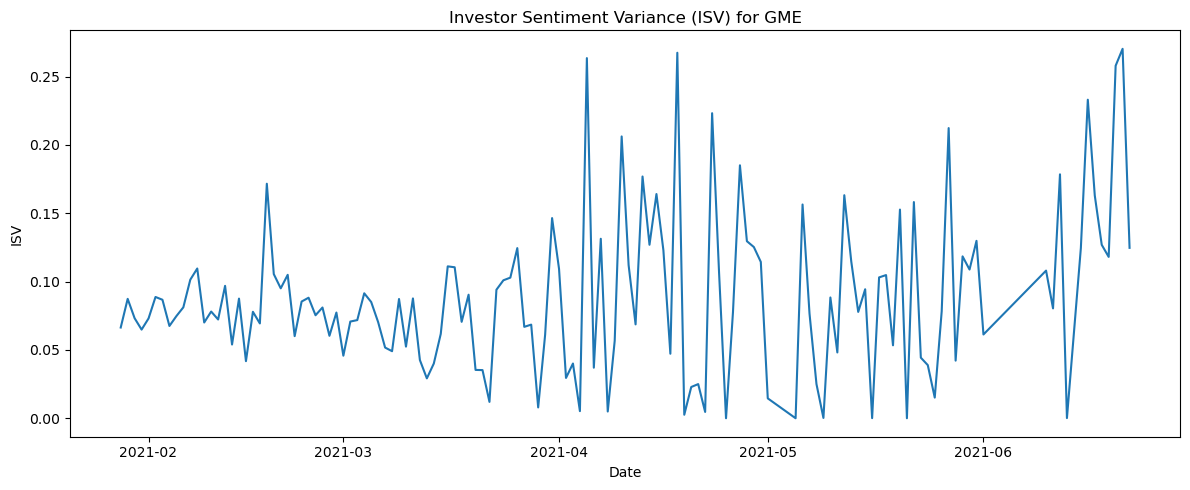

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

gme_features["date"] = pd.to_datetime(gme_features["date"])

plt.figure(figsize=(12,5))

plt.plot(gme_features["date"], gme_features["isv"])

plt.title("Investor Sentiment Variance (ISV) for GME")
plt.xlabel("Date")
plt.ylabel("ISV")

plt.tight_layout()
plt.show()